In [3]:
# Pandas for data handling
import pandas # https://pandas.pydata.org/
from pandas.plotting import scatter_matrix

# pretty tables
from IPython.display import display

# NumPy for numerical computing
import numpy # https://numpy.org/

# MatPlotLib + Seaboorn for visualization
import matplotlib.pyplot as pl  # https://matplotlib.org/
import seaborn as sns # https://seaborn.pydata.org/

# assessment
from sklearn import model_selection # for model comparisons
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score

# algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
# Import libraries

# First, let’s import all of the modules, functions and objects we are going to use in this tutorial.

# Pandas for data handling
import pandas # https://pandas.pydata.org/
from pandas.plotting import scatter_matrix

# pretty tables
from IPython.display import display

# NumPy for numerical computing
import numpy # https://numpy.org/

# MatPlotLib for visualization
%matplotlib inline
import matplotlib.pyplot as pl  # https://matplotlib.org/

# assessment
from sklearn import model_selection # for model comparisons
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# algorithms
from sklearn import preprocessing
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor

In [4]:
print('Loading data from file ...')  # load the data
dataset = pandas.read_csv('BDOShoham.csv')
print('done \n')

print('Removing rows with missing data ...')  # Remove missing data
dataset = dataset.dropna()  # default is to drop any row that contains at least one missing value
print('done \n')

Loading data from file ...
done 

Removing rows with missing data ...
done 



In [5]:
########## Part 1 ##########

# Display for pretty tables
from IPython.display import display

print('Sample rows from the dataset (top and bottom three):')  # Spot checks
display(dataset.head(3))
display(dataset.tail(3))
print('\n')

Sample rows from the dataset (top and bottom three):


,FlowPattern,Vsl,Vsg,VisL,VisG,DenL,DenG,ST,Ang,ID
0,1,6.3,0.025,0.001,0.00002,1000,1.8,0.07,0.0,0.051
1,1,4.0,0.040,0.001,0.00002,1000,1.8,0.07,0.0,0.051
2,1,6.3,0.040,0.001,0.00002,1000,1.8,0.07,0.0,0.051


,FlowPattern,Vsl,Vsg,VisL,VisG,DenL,DenG,ST,Ang,ID
5672,5,1.05338,16.0692,0.001,0.00002,1000,1.8,0.07,-80.0,0.025
5673,5,1.05397,25.7439,0.001,0.00002,1000,1.8,0.07,-80.0,0.025
5674,5,1.66789,26.1616,0.001,0.00002,1000,1.8,0.07,-80.0,0.025


In [6]:
# Numerical summary table

print('Summary of the dataset - Univariate statistics')   
display(dataset.describe(include='all'))
print('\n')

Summary of the dataset - Univariate statistics


,FlowPattern,Vsl,Vsg,VisL,VisG,DenL,DenG,ST,Ang,ID
count,5675.000000,5675.000000,5675.000000,5.675000e+03,5.675000e+03,5675.0,5.675000e+03,5.675000e+03,5675.000000,5675.000000
mean,4.059912,0.899747,6.222612,1.000000e-03,2.000000e-05,1000.0,1.800000e+00,7.000000e-02,2.727401,0.038657
std,1.379238,1.425159,8.699644,4.055273e-17,2.361736e-18,0.0,4.108187e-14,5.690394e-15,46.202822,0.012985
min,1.000000,0.001100,0.003720,1.000000e-03,2.000000e-05,1000.0,1.800000e+00,7.000000e-02,-90.000000,0.025000
25%,3.000000,0.016000,0.162055,1.000000e-03,2.000000e-05,1000.0,1.800000e+00,7.000000e-02,-10.000000,0.025000
50%,5.000000,0.250000,1.600000,1.000000e-03,2.000000e-05,1000.0,1.800000e+00,7.000000e-02,0.500000,0.051000
75%,5.000000,1.500000,10.000000,1.000000e-03,2.000000e-05,1000.0,1.800000e+00,7.000000e-02,20.000000,0.051000
max,7.000000,25.517000,42.956200,1.000000e-03,2.000000e-05,1000.0,1.800000e+00,7.000000e-02,90.000000,0.051000


In [7]:
########## Part 2 ##########

In [8]:
print('Reading list of problem variables X and Y...')
X_name = [ 'Vsl', 'Vsg', 'Ang' ] # columns to focus on as predictors
X = dataset[X_name]   # only keep these columns as features
y_name = 'FlowPattern'     # column to focus on as target
y = dataset[y_name]   # only keep this column as label 
print('done \n')

Reading list of problem variables X and Y...
done 



In [9]:
# # Spot checks for X:

# print('Sample rows from X (top and bottom):')
# display(X.head(3))
# display(X.tail(3))
# print('\n')

# print('Statistical summary of X:')
# display(X.describe())
# print('\n')

In [10]:
# # Let's look at some graphical summaries

# %matplotlib inline
# import matplotlib.pyplot as pl  # https://matplotlib.org/

# print('Summary of X - Univariate graphs')
# print()

# print('Histograms:')
# X.hist(figsize=(15, 5), bins=75)  # bins ~= sqrt(N)
# pl.show()

# print('Box plots:')
# X.plot(figsize=(15, 5), kind='box', subplots=True, sharex=False, sharey=False)
# pl.show()

In [11]:
# # More graphical summaries

# import seaborn as sns   # https://seaborn.pydata.org/

# print('Summary of X - Bivariate (column-pair) graphs:')

# print('Correlation matrix:')
# corr = X.corr()
# sns.heatmap( corr, cmap='coolwarm', vmax=1.0, vmin=-1.0 );
# pl.show()

# print('Scatter plots:')
# scatter_matrix(X, figsize=(16, 16))
# pl.show()

In [12]:
# # Spot checks for y:

# print('Summary of y:')
# display(y.value_counts())

In [13]:
# Machine Learning
# Split data into training and testing datasets
from sklearn import model_selection

test_pct = 0.20   # reserve 20% of the data points for testing performance, 80% for training
seed = 9          # specifying the seed allows for repeatability # The reproducable way
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_pct, random_state=seed)
print('done with setting aside data for testing')

done with setting aside data for testing


In [14]:
###### part 3 ######

In [15]:
# neigh = KNeighborsClassifier(n_neighbors=3)  # Our model will only consider the THREE nearest neighbors

method: mean (standard dev) max
Linear: -0.019898 (1.234794) 3.391638


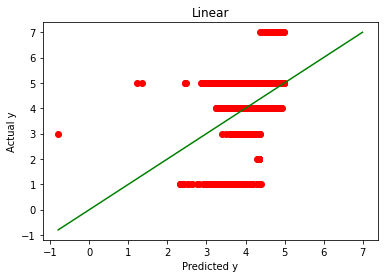

method: mean (standard dev) max
Lasso: -0.016156 (1.320183) 3.690987


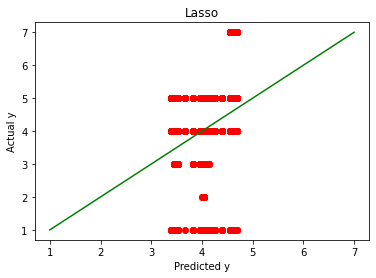

method: mean (standard dev) max
Ridge: -0.019897 (1.234796) 3.391610


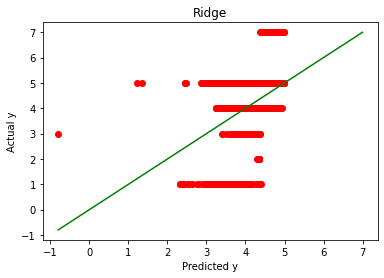

method: mean (standard dev) max
KNR: 0.025022 (0.755794) 4.000000


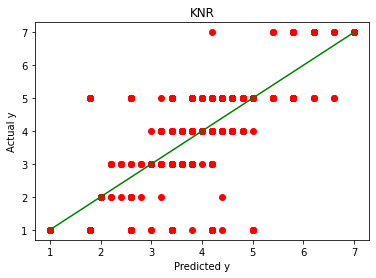

In [16]:
# Train models on the data and estimate their accuracy on unseen data.

# Algorithms
models = []
models.append(('Linear', LinearRegression() )) 
models.append(('Lasso', Lasso(random_state=seed) ))
models.append(('Ridge', Ridge() ))
models.append(('KNR', KNeighborsRegressor() ))

results = []
for name, modelName in models:   # evaluate each model in turn
    modelName.fit(X_train, y_train)  # train the model on the training data
    y_predicted = modelName.predict(X_test)  # make predictions using the testing data
    y_actual = numpy.asarray(y_test)
    y_error = pandas.DataFrame(data=y_predicted - y_actual)
    results.append(y_error)
        # result statistics
    print('method: mean (standard dev) max')
    msg = "%s: %f (%f) %f" % (name, y_error.mean(), y_error.std(), y_error.max())
    print(msg)
    # Plot outputs
    LL = min([min(y_predicted), min(y_actual)])
    UR = max([max(y_predicted), max(y_actual)])
    pl.title(name)
    pl.plot(y_predicted, y_actual,'ro')
    pl.plot([LL,UR],[LL,UR], 'g-')
    pl.xlabel('Predicted y')
    pl.ylabel('Actual y')
    pl.show()

In [17]:
# Overall, the mean accuracy is not good for all of these algorithms. Standard deviation is slightly 
# better for KNR, Ridge has the best(least) maximum difference. But overall, all these models aren't
# very good. If I'd pick one algorithm, I would probably pick KNR. 

In [18]:
###### part 4 ######

method: mean (standard dev) max
KNR: 0.050779 (0.848041) 4.000000


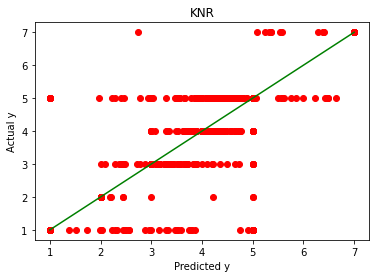

In [34]:
# Algorithms
models = []
models.append(('KNR', KNeighborsRegressor(n_neighbors=3, weights = 'distance', metric = 'euclidean', algorithm = 'auto') ))

results = []
for name, modelName in models:   # evaluate each model in turn
    modelName.fit(X_train, y_train)  # train the model on the training data
    y_predicted = modelName.predict(X_test)  # make predictions using the testing data
    y_actual = numpy.asarray(y_test)
    y_error = pandas.DataFrame(data=y_predicted - y_actual)
    results.append(y_error)
        # result statistics
    print('method: mean (standard dev) max')
    msg = "%s: %f (%f) %f" % (name, y_error.mean(), y_error.std(), y_error.max())
    print(msg)
    # Plot outputs
    LL = min([min(y_predicted), min(y_actual)])
    UR = max([max(y_predicted), max(y_actual)])
    pl.title(name)
    pl.plot(y_predicted, y_actual,'ro')
    pl.plot([LL,UR],[LL,UR], 'g-')
    pl.xlabel('Predicted y')
    pl.ylabel('Actual y')
    pl.show()

In [35]:
# Conclusion: After changing the n_neighbors, weights, metric and algorithm of KNN regression,
# mean changed from 2.5% to 5.1%, std_dev changed from 0.76 to 0.84, while max remain the same. 
# This is big improvement over default settings

In [36]:
###### I will be testing KNN (best method so far) trying different hyperparameters. ######

method: mean (standard dev) max
Linear: -0.019898 (1.234794) 3.391638


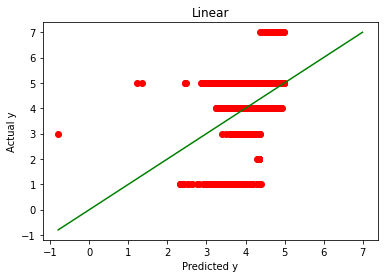

method: mean (standard dev) max
Lasso: -0.016156 (1.320183) 3.690987


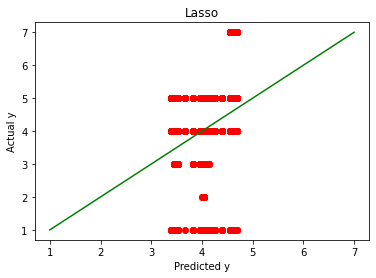

method: mean (standard dev) max
Ridge: -0.019897 (1.234796) 3.391610


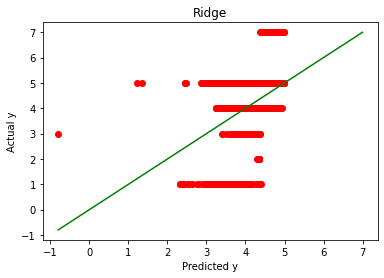

method: mean (standard dev) max
KNR: 0.050779 (0.848041) 4.000000


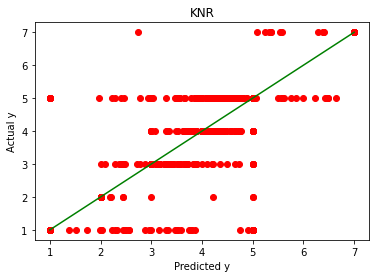

In [40]:
# Algorithms
models = []
models.append(('Linear', LinearRegression() )) 
models.append(('Lasso', Lasso(random_state=seed) ))
models.append(('Ridge', Ridge() ))
models.append(('KNR', KNeighborsRegressor(n_neighbors=3, weights = 'distance', metric = 'euclidean', algorithm = 'auto' )))

results = []
for name, modelName in models:   # evaluate each model in turn
    modelName.fit(X_train, y_train)  # train the model on the training data
    y_predicted = modelName.predict(X_test)  # make predictions using the testing data
    y_actual = numpy.asarray(y_test)
    y_error = pandas.DataFrame(data=y_predicted - y_actual)
    results.append(y_error)
        # result statistics
    print('method: mean (standard dev) max')
    msg = "%s: %f (%f) %f" % (name, y_error.mean(), y_error.std(), y_error.max())
    print(msg)
    # Plot outputs
    LL = min([min(y_predicted), min(y_actual)])
    UR = max([max(y_predicted), max(y_actual)])
    pl.title(name)
    pl.plot(y_predicted, y_actual,'ro')
    pl.plot([LL,UR],[LL,UR], 'g-')
    pl.xlabel('Predicted y')
    pl.ylabel('Actual y')
    pl.show()

In [ ]:
# Overall results: After changing the n_neighbors, weights, metric and algorithm of KNN regression,
# mean changed from 2.5% to 5.1%, std_dev changed from 0.76 to 0.84, while max remain the same. 
# This is big improvement over default settings. Since KNN with default settings was already one of
# the better algorithms, after the parameter improvement, the results of KNN are much better than
# the other 3 algorithms. But there's still room for improvement. 